<a href="https://colab.research.google.com/github/IvanIri/Procesamiento-del-Habla/blob/main/TP2_PH_Ivan_Irigoyen.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TP 2: Procesamiento de archivos PDF.


Iván Irigoyen.

Procesamiento del Habla.

In [1]:
!pip install pymupdf -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.8/25.8 MB 36.3 MB/s eta 0:00:00


In [2]:
import requests
import fitz
import os

## Adquisición e inspección de los metadatos

In [3]:
# URL del PDF
url = "https://iea.ude.edu.ar/wp-content/uploads/2024/09/Informe-Macroeconomico-y-Financiero-IEA-Septiembre-2024.pdf"

nombre_archivo = "informe_economico_ude.pdf"

# Descargar el documento
respuesta = requests.get(url, timeout=30)
respuesta.raise_for_status()

# Guardar el PDF
with open(nombre_archivo, "wb") as archivo:
    archivo.write(respuesta.content)

print("PDF descargado correctamente")
print("Tamaño:", round(os.path.getsize(nombre_archivo) / 1024, 2), "KB")

PDF descargado correctamente
Tamaño: 504.61 KB


In [4]:
documento = fitz.open(nombre_archivo)

# Obtener metadatos
metadatos = documento.metadata

print("Título:", metadatos.get("title"))
print("Autor:", metadatos.get("author"))
print("Número de páginas:", documento.page_count)
print("Software de creación:", metadatos.get("creator"))
print("Software productor:", metadatos.get("producer"))

Título: 
Autor: Nahia .
Número de páginas: 16
Software de creación: Microsoft® Word 2016
Software productor: Microsoft® Word 2016


In [5]:
# Extraer texto de la tercera página
pagina = documento.load_page(2)
texto = pagina.get_text("text")

print(texto[:1000])

 
 
 
  |  3  
 
Informe mensual de coyuntura económica del Instituto de Economía 
Aplicada (UDE) 
El mes de septiembre trajo consigo importantes novedades en materia económica para un gobierno 
nacional que atraviesa la segunda etapa de su programa económico.  
En este aspecto se destacan el (delgado) retorno al superávit fiscal, las modificaciones en el impuesto 
PAIS que retrotrajeron su alícuota para importaciones a los valores previos a la asunción del gobierno, 
la baja de los dólares financieros y el crecimiento de los depósitos en dólares producto del blanqueo. 
Asimismo, se publicaron los datos de empleo y pobreza, con un incremento leve en el primer caso y 
uno preocupante en el segundo. 
Sin embargo, la presentación del presupuesto 2025 fue el hecho relevante que se robó la atención de 
los analistas económicos. Tanto los supuestos macroeconómicos abordados como así también los 
patrones de ingresos y gastos, estos últimos con una flexibilidad inusitada a la baja en caso de 

## Analisis estructural del texto

In [6]:
# Selecciono una pag del pdf
pagina = documento.load_page(2)

# Extraer el texto sin aplicar limpieza
texto_crudo = pagina.get_text("text", sort=False)

print(repr(texto_crudo[:1500]))

' \n \n \n  |  3  \n \nInforme mensual de coyuntura económica del Instituto de Economía \nAplicada (UDE) \nEl mes de septiembre trajo consigo importantes novedades en materia económica para un gobierno \nnacional que atraviesa la segunda etapa de su programa económico.  \nEn este aspecto se destacan el (delgado) retorno al superávit fiscal, las modificaciones en el impuesto \nPAIS que retrotrajeron su alícuota para importaciones a los valores previos a la asunción del gobierno, \nla baja de los dólares financieros y el crecimiento de los depósitos en dólares producto del blanqueo. \nAsimismo, se publicaron los datos de empleo y pobreza, con un incremento leve en el primer caso y \nuno preocupante en el segundo. \nSin embargo, la presentación del presupuesto 2025 fue el hecho relevante que se robó la atención de \nlos analistas económicos. Tanto los supuestos macroeconómicos abordados como así también los \npatrones de ingresos y gastos, estos últimos con una flexibilidad inusitada a la

In [7]:
# Identificación de caracteres especiales
separadores = {
    "Saltos de línea (\\n)": "\n",
    "Retornos (\\r)": "\r",
    "Tabulaciones (\\t)": "\t",
    "Dobles espacios": "  ",
    "Dobles saltos de línea": "\n\n"
}

for nombre, caracter in separadores.items():
    cantidad = texto_crudo.count(caracter)
    print(f"{nombre}: {cantidad}")

Saltos de línea (\n): 26
Retornos de carro (\r): 0
Tabulaciones (\t): 0
Dobles espacios: 4
Dobles saltos de línea: 0


In [9]:
# Dividir el texto según los saltos de línea
lineas = texto_crudo.split("\n")

print("Cantidad de líneas:", len(lineas))

for i, linea in enumerate(lineas[:15], start=1):
    print(f"Línea {i}: {repr(linea)}")

Cantidad de líneas: 27
Línea 1: ' '
Línea 2: ' '
Línea 3: ' '
Línea 4: '  |  3  '
Línea 5: ' '
Línea 6: 'Informe mensual de coyuntura económica del Instituto de Economía '
Línea 7: 'Aplicada (UDE) '
Línea 8: 'El mes de septiembre trajo consigo importantes novedades en materia económica para un gobierno '
Línea 9: 'nacional que atraviesa la segunda etapa de su programa económico.  '
Línea 10: 'En este aspecto se destacan el (delgado) retorno al superávit fiscal, las modificaciones en el impuesto '
Línea 11: 'PAIS que retrotrajeron su alícuota para importaciones a los valores previos a la asunción del gobierno, '
Línea 12: 'la baja de los dólares financieros y el crecimiento de los depósitos en dólares producto del blanqueo. '
Línea 13: 'Asimismo, se publicaron los datos de empleo y pobreza, con un incremento leve en el primer caso y '
Línea 14: 'uno preocupante en el segundo. '
Línea 15: 'Sin embargo, la presentación del presupuesto 2025 fue el hecho relevante que se robó la atención de

### Conclusiones:

Se analizo el texto de la 3ra pagina del archivo PDF. Se encontraron 26 saltos de lineas (\n) y 4 dobles espacios. No se encontraron dobles saltados de linea (\n\n), tabulaciones (\t), ni retornos (\r).

El principal separador utilizado en el texto es el salto de linea, pero no se utiliza solo para representar el final de un parrafo, ya que también se utiliza para dividir visualmente las lineas de una misma oración.

## Extración de datos tabulares

In [10]:
!pip install pdfplumber -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 1.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.4/62.4 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 34.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 76.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 60.7 MB/s eta 0:00:00


In [11]:
import pdfplumber
import pandas as pd

In [13]:
# buscamos que pag contienen tablas

with pdfplumber.open(nombre_archivo) as pdf:

    for i, pagina in enumerate(pdf.pages):

        tablas = pagina.extract_tables()

        if tablas:
            print(f"Página {i+1}: {len(tablas)} tabla(s) detectada(s)")

Página 12: 1 tabla(s) detectada(s)
Página 13: 1 tabla(s) detectada(s)


In [14]:
# Vemos las pag con las tablas

with pdfplumber.open(nombre_archivo) as pdf:

    # Extraer tablas de las páginas 12 y 13
    tabla_12 = pdf.pages[11].extract_table()
    tabla_13 = pdf.pages[12].extract_table()

# Mostrar contenido de las tablas
print("TABLA - PÁGINA 12")

for fila in tabla_12:
    print(fila)

print("\nTABLA - PÁGINA 13")

for fila in tabla_13:
    print(fila)

TABLA - PÁGINA 12
['', None, None, '', None, None, '', None, None, '', None, None]
['', 'Fecha', '', '', 'Dólar oficial', '', '', 'Var mensual', '', '', 'Var acumulada', '']
['', None, None, '', None, None, '', None, None, '', None, None]
['Diciembre 24', None, None, '$1.020', None, None, '', None, None, '', None, None]
['Enero 25', None, None, '$1.040', None, None, '2,0%', None, None, '2,0%', None, None]
['Febrero 25', None, None, '$1.061', None, None, '2,0%', None, None, '4,0%', None, None]
['Marzo 25', None, None, '$1.082', None, None, '2,0%', None, None, '6,1%', None, None]
['Abril 25', None, None, '$1.104', None, None, '2,0%', None, None, '8,2%', None, None]
['Mayo 25', None, None, '$1.126', None, None, '2,0%', None, None, '10,4%', None, None]
['Junio 25', None, None, '$1.137', None, None, '1,0%', None, None, '11,5%', None, None]

TABLA - PÁGINA 13
['Julio 25', '$1.149', '1,0%', '12,6%']
['Agosto 25', '$1.160', '1,0%', '13,8%']
['Septiembre 25', '$1.172', '1,0%', '14,9%']
['Octubr

Se identificaron 2 tablas, pero al observar el formato el cual es muy similar y la 2da parece incompleta (sin titulo de columna) sospeche que se trataba de la misma tabla divida en 2 paginas, lo cual chequee viendo el PDF y era así, por lo que voy a utilizar las "2 tablas" encontradas.

In [15]:
# Limmpieza de las tablas

# Seleccionar las filas con datos y las columnas relevantes
datos_12 = [
    [fila[0], fila[3], fila[6], fila[9]]
    for fila in tabla_12[3:]
]

# Convertir a DataFrame
df_12 = pd.DataFrame(
    datos_12,
    columns=["Fecha", "Dolar_oficial", "Var_mensual", "Var_acumulada"]
)

display(df_12)

,Fecha,Dolar_oficial,Var_mensual,Var_acumulada
0,Diciembre 24,$1.020,,
1,Enero 25,$1.040,"2,0%","2,0%"
2,Febrero 25,$1.061,"2,0%","4,0%"
3,Marzo 25,$1.082,"2,0%","6,1%"
4,Abril 25,$1.104,"2,0%","8,2%"
5,Mayo 25,$1.126,"2,0%","10,4%"
6,Junio 25,$1.137,"1,0%","11,5%"


In [16]:
df_13 = pd.DataFrame(
    tabla_13,
    columns=["Fecha", "Dolar_oficial", "Var_mensual", "Var_acumulada"]
)

display(df_13)

,Fecha,Dolar_oficial,Var_mensual,Var_acumulada
0,Julio 25,$1.149,"1,0%","12,6%"
1,Agosto 25,$1.160,"1,0%","13,8%"
2,Septiembre 25,$1.172,"1,0%","14,9%"
3,Octubre 25,$1.183,"1,0%","16,0%"
4,Noviembre 25,$1.195,"1,0%","17,2%"
5,Diciembre 25,$1.207,"1,0%","18,3%"


In [18]:
# Uno las tablas

df_dolar = pd.concat(
    [df_12, df_13],
    ignore_index=True
)

# Elimino filas vacias
df_dolar = df_dolar.dropna(how="all")

display(df_dolar)

,Fecha,Dolar_oficial,Var_mensual,Var_acumulada
0,Diciembre 24,$1.020,,
1,Enero 25,$1.040,"2,0%","2,0%"
2,Febrero 25,$1.061,"2,0%","4,0%"
3,Marzo 25,$1.082,"2,0%","6,1%"
4,Abril 25,$1.104,"2,0%","8,2%"
5,Mayo 25,$1.126,"2,0%","10,4%"
6,Junio 25,$1.137,"1,0%","11,5%"
7,Julio 25,$1.149,"1,0%","12,6%"
8,Agosto 25,$1.160,"1,0%","13,8%"
9,Septiembre 25,$1.172,"1,0%","14,9%"


In [19]:
# Valido extracción

print("Dimensiones:", df_dolar.shape)
print("\nValores nulos:")
print(df_dolar.isnull().sum())
print("\nTipos de datos:")
print(df_dolar.dtypes)

Dimensiones: (13, 4)

Valores nulos:
Fecha            0
Dolar_oficial    0
Var_mensual      0
Var_acumulada    0
dtype: int64

Tipos de datos:
Fecha            object
Dolar_oficial    object
Var_mensual      object
Var_acumulada    object
dtype: object


### Conclusión:

Encontre una unica tabla divida en 2 paginas por lo que primero se convirtieron los datos en DataFrame para una mejor visualización, luego realizamos una unión de la tabla dividida en 2 y posteriormente se realizaron tareas de limpiza, como eliminación de nulos, eliminiación de encabezados vacios, espacios vacios y se les asigno nombre a las variables.

La tabla final esta compuesta por 13 filas y 4 columnas.

## Análisis de frecuencias (NLP básico)

In [20]:
import nltk
import re
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from collections import Counter

# Descargar recursos necesarios
nltk.download("stopwords")
nltk.download("punkt")
nltk.download("punkt_tab")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [21]:
# Extraer el texto de la página 3
pagina = documento.load_page(2)

texto = pagina.get_text("text")

# Convertir a minúsculas
texto_minusculas = texto.lower()

print(texto_minusculas[:1000])

 
 
 
  |  3  
 
informe mensual de coyuntura económica del instituto de economía 
aplicada (ude) 
el mes de septiembre trajo consigo importantes novedades en materia económica para un gobierno 
nacional que atraviesa la segunda etapa de su programa económico.  
en este aspecto se destacan el (delgado) retorno al superávit fiscal, las modificaciones en el impuesto 
pais que retrotrajeron su alícuota para importaciones a los valores previos a la asunción del gobierno, 
la baja de los dólares financieros y el crecimiento de los depósitos en dólares producto del blanqueo. 
asimismo, se publicaron los datos de empleo y pobreza, con un incremento leve en el primer caso y 
uno preocupante en el segundo. 
sin embargo, la presentación del presupuesto 2025 fue el hecho relevante que se robó la atención de 
los analistas económicos. tanto los supuestos macroeconómicos abordados como así también los 
patrones de ingresos y gastos, estos últimos con una flexibilidad inusitada a la baja en caso de 

In [22]:
# Tokenizar el texto
tokens = word_tokenize(texto_minusculas, language="spanish")

print("Cantidad de tokens:", len(tokens))
print("\nPrimeros 30 tokens:")
print(tokens[:30])

Cantidad de tokens: 272

Primeros 30 tokens:
['|', '3', 'informe', 'mensual', 'de', 'coyuntura', 'económica', 'del', 'instituto', 'de', 'economía', 'aplicada', '(', 'ude', ')', 'el', 'mes', 'de', 'septiembre', 'trajo', 'consigo', 'importantes', 'novedades', 'en', 'materia', 'económica', 'para', 'un', 'gobierno', 'nacional']


In [23]:
# Stop words
stop_words = set(stopwords.words("spanish"))

# Filtrar tokens
tokens_limpios = [
    token
    for token in tokens
    if token not in stop_words
    and re.fullmatch(r"[a-záéíóúüñ]+", token)
]

print("Tokens originales:", len(tokens))
print("Tokens limpios:", len(tokens_limpios))

print("\nPrimeros 30 tokens limpios:")
print(tokens_limpios[:30])

Tokens originales: 272
Tokens limpios: 127

Primeros 30 tokens limpios:
['informe', 'mensual', 'coyuntura', 'económica', 'instituto', 'economía', 'aplicada', 'ude', 'mes', 'septiembre', 'trajo', 'consigo', 'importantes', 'novedades', 'materia', 'económica', 'gobierno', 'nacional', 'atraviesa', 'segunda', 'etapa', 'programa', 'económico', 'aspecto', 'destacan', 'delgado', 'retorno', 'superávit', 'fiscal', 'modificaciones']


In [24]:
# Contar frecuencias
frecuencias = Counter(tokens_limpios)

# Obtener las 15 palabras más frecuentes
top_15 = frecuencias.most_common(15)

# Convertir a DataFrame
df_frecuencias = pd.DataFrame(
    top_15,
    columns=["Palabra", "Frecuencia"]
)

display(df_frecuencias)

,Palabra,Frecuencia
0,gobierno,3
1,nacional,3
2,informe,2
3,económica,2
4,materia,2
5,baja,2
6,dólares,2
7,caso,2
8,presupuesto,2
9,así,2


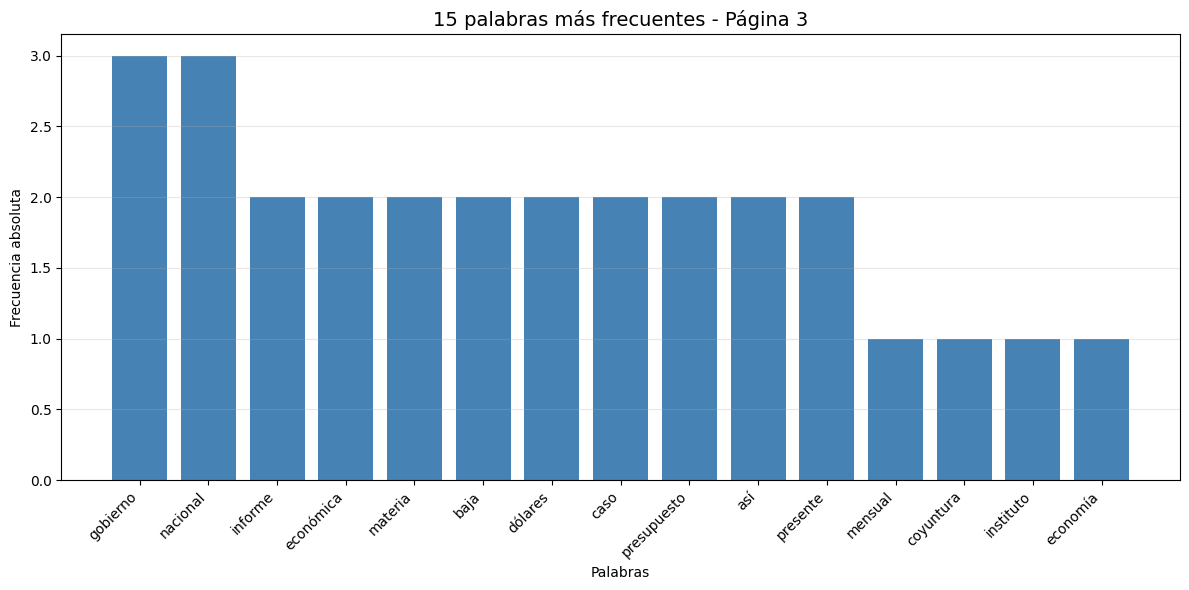

In [25]:
# Genero el grafico para visualizar las palabras mas frecuentes

plt.figure(figsize=(12, 6))

plt.bar(
    df_frecuencias["Palabra"],
    df_frecuencias["Frecuencia"],
    color="steelblue"
)

plt.title("15 palabras más frecuentes - Página 3", fontsize=14)
plt.xlabel("Palabras")
plt.ylabel("Frecuencia absoluta")

plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## Conclusión:

luego de realizar la tokenización, normalización, eliminación de stop words se identificaron las 15 palabras mas frecuentes.

Entre estas hay un candidato fijo a stop words y 2 que dependen del contexto.

Candidato fijo: "así", el cual es un conector de oraciones.

Candidatos que dependen: "caso" y "presente", ambas palabras tienen un uso muy variado, pueden funcionar como conectores de oraciones o dependiendo de como esten acompañados como parte importante del texto.

Así que como conclusión sumaría a stop words a "así" unicamente y conservaría las otras 2 palabras.

Las palabras más frecuentes fueron "gobierno" y "nacional" las cuales estan ligadas directamente al tema que trata el PDF.